In [1]:
import quantum_toolkit as quat
import quantum_transport_toolkit as trat

print(quat.hartree_atomic_units["action"])

# rfm = 0.02;
# rfe = 1.25;
# rfhb = 20.0;
# rfk = 400;
# dx = 0.025;

1


# Set unified grid

In [ ]:
import numpy as np

uxgrid_num = 24*1024
uxgrid_dx = 0.025
uxgrid_width_hau=uxgrid_num*uxgrid_dx
hau_in_nm=5.29177210544e-2
uxgrid_width_nm=uxgrid_width_hau*hau_in_nm

uxgrid = np.linspace(-uxgrid_width_hau/2, uxgrid_width_hau/2, uxgrid_num)
uxgrid_dx = uxgrid[1]-uxgrid[0]
print(uxgrid_dx)

dispersion=quat.Dispersion(uxgrid_dx)

print(type(uxgrid)) 
print(uxgrid_dx)
print(uxgrid_width_hau)
print(uxgrid_width_nm)

0.025001017294016492
<class 'numpy.ndarray'>
0.025001017294016492
614.4000000000001
32.512647815823364


#Paraméter szett csak az elejére

potenciál magassága max pár eV GaN és arany vagy amit a Vaclav használt
geometriát is kb realisztikusra
potenciál gát magassága legyen 1 vagy 2 eV

Ha ez nem mutat semmit akkor periódikussat
a szélessége egy oxid réteg széles 




# Set model-potential

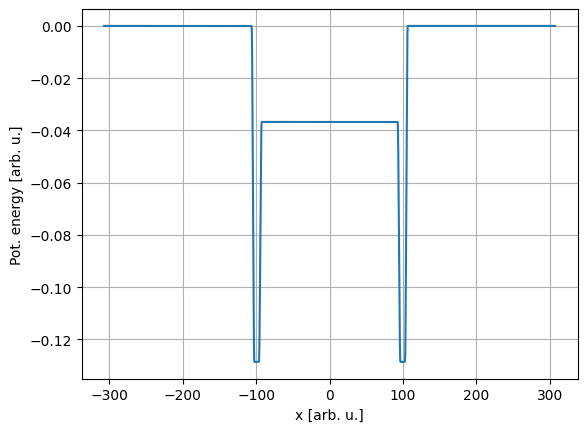

In [3]:
import matplotlib.pyplot as plt
import potentials as pots

#Standard electrode lists
#https://chem.libretexts.org/Ancillary_Materials/Reference/Reference_Tables/Electrochemistry_Tables/P1%3A_Standard_Reduction_Potentials_by_Element
#https://www.engineeringtoolbox.com/electrode-potential-d_482.html
#https://en.wikipedia.org/wiki/Standard_electrode_potential_(data_page)
#https://chem.libretexts.org/Ancillary_Materials/Reference/Reference_Tables/Electrochemistry_Tables/P1%3A_Standard_Reduction_Potentials_by_Element
#https://nano3dsystems.com/wp-content/uploads/2019/06/Ir.pdf
standard_potential_of_Au_in_V=1.83
standard_potential_of_Al_in_V=-1.66 #http://hyperphysics.phy-astr.gsu.edu/hbase/Tables/electpot.html
standard_potential_of_Ir_in_V=0.87 #10.1002/elan.200403200
standard_potential_of_O3_in_V=1.246 #https://www.chm.uri.edu/weuler/chm112/refmater/redpottable.html

hau_in_eV=27.211386245988
modelpot=pots.SmoothStackPotential(uxgrid,wallwidth=10,\
                                   wallheight=-3.5/hau_in_eV,\
                                   welldepth=1/hau_in_eV,\
                                   wellwidth=10/hau_in_nm,\
                                   wallrise = 5,\
                                   wellfall = 5)
#modelpot=StackPotential(uxgrid)

plt.plot(uxgrid,modelpot(0))
plt.xlabel("x [arb. u.]")
plt.ylabel("Pot. energy [arb. u.]")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.grid()
plt.show()

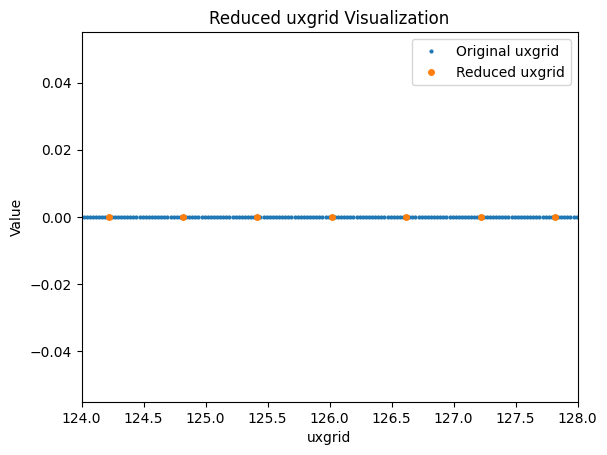

Original uxgrid length: 24576
Reduced uxgrid length: 1024


In [4]:
# Generate uxgrid
uxgrid = np.linspace(-uxgrid_width_hau / 2, uxgrid_width_hau / 2, uxgrid_num)

# Desired number of points
desired_points = 1000

# Calculate the step size to reduce the number of points
step_size = uxgrid_num // desired_points

# Create the mask
mask = np.zeros(uxgrid_num, dtype=bool)
mask[::step_size] = True

# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=2, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=4, label='Reduced uxgrid')
plt.xlim([124, 128])
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

print("Original uxgrid length:", len(uxgrid))
print("Reduced uxgrid length:", len(reduced_uxgrid))

In [5]:
# Highlighted ranges
highlight_ranges = [(-152, -148), (148, 152)]

# Initialize mask
mask_highlight_ranges = np.zeros(uxgrid_num, dtype=bool)

# Apply mask for highlighted ranges
for start, end in highlight_ranges:
    mask_highlight_ranges |= (uxgrid >= start) & (uxgrid <= end)

# Number of highlighted points
highlighted_num = np.sum(mask_highlight_ranges)

print(f"Number of uxgrid points: {uxgrid_num}")
print(f"Number of highlighted points: {highlighted_num}")

Number of uxgrid points: 24576
Number of highlighted points: 320


In [6]:
mask += mask_highlight_ranges

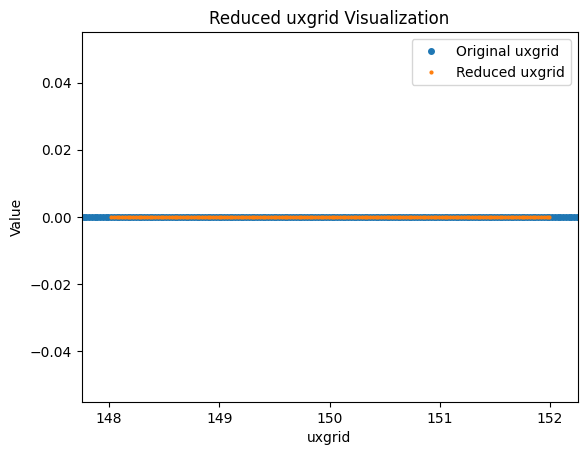

Original uxgrid length: 24576
Reduced uxgrid length: 1330


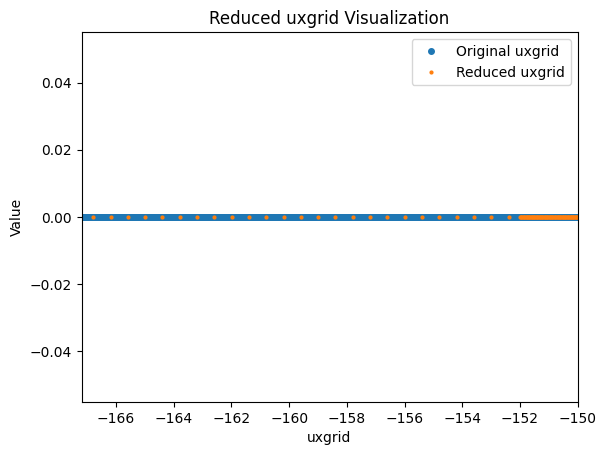

Original uxgrid length: 24576
Reduced uxgrid length: 1330


In [9]:
# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=4, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=2, label='Reduced uxgrid')
plt.xlim([highlight_ranges[1][0]-10*uxgrid_dx, highlight_ranges[1][1]+10*uxgrid_dx])
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

print("Original uxgrid length:", len(uxgrid))
print("Reduced uxgrid length:", len(reduced_uxgrid))

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=4, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=2, label='Reduced uxgrid')
plt.xlim([1.1*highlight_ranges[0][0], highlight_ranges[0][0]+2])
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

print("Original uxgrid length:", len(uxgrid))
print("Reduced uxgrid length:", len(reduced_uxgrid))

# Compute state at given input energy with NEGF

In [9]:
#zeropot=quat.ZeroPotential(uxgrid)
zeropot=pots.ZeroPotential(uxgrid)
ham_static = quat.HamiltonOperator(uxgrid, scalarpot=modelpot, vectorpot=zeropot )

In [10]:
import scipy.sparse as sparse

mat=ham_static(0)
eigenvalues, eigenvectors = sparse.linalg.eigsh(mat, 20,which = 'SR')

print(eigenvalues[0])

KeyboardInterrupt: 

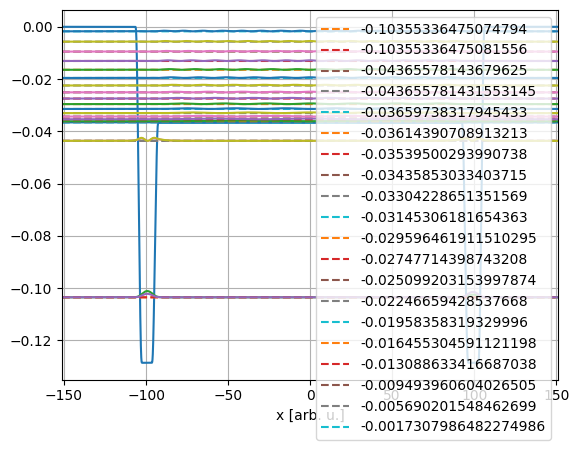

In [6]:
# plt.plot(uxgrid,modelpot(0),label="Pot")
# plt.plot(uxgrid,np.real(eigenvectors[:,0]),label="Re")
# plt.plot(uxgrid,np.imag(eigenvectors[:,0]),label="Im")
# plt.plot(uxgrid,np.abs(eigenvectors[:,0]),label="Abs")

plt.plot(uxgrid,modelpot(0))
for eval,evec  in zip(eigenvalues,np.transpose(eigenvectors)):
    plt.plot(uxgrid,eval*np.ones_like(uxgrid),"--",label=str(eval))
    #plt.plot(uxgrid,0.5*np.real(evec)+eval)#,label="Re")
    #plt.plot(uxgrid,0.5*np.imag(evec)+eval)#,label="Im")
    plt.plot(uxgrid,np.abs(evec)**2+eval)#,label="Abs")
plt.xlabel("x [arb. u.]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend(loc='upper right')
plt.grid()
plt.show()

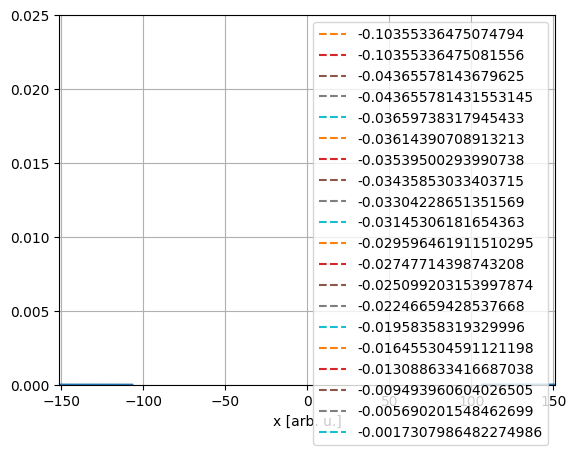

In [7]:
plt.plot(uxgrid,modelpot(0))
for eval,evec  in zip(eigenvalues,np.transpose(eigenvectors)):
    plt.plot(uxgrid,eval*np.ones_like(uxgrid),"--",label=str(eval))
    #plt.plot(uxgrid,0.5*np.real(evec)+eval)#,label="Re")
    #plt.plot(uxgrid,0.5*np.imag(evec)+eval)#,label="Im")
    plt.plot(uxgrid,np.abs(evec)**2+eval)#,label="Abs")
plt.xlabel("x [arb. u.]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.ylim(0,0.025)
plt.legend(loc='upper right')
plt.grid()
plt.show()

In [8]:
ein=0.2
kin=dispersion.energy2k(ein)

quasiparticle_pk, quasiparticle_mk = trat.quasiparticles_at_given_energy(ein,kin,ham_static)

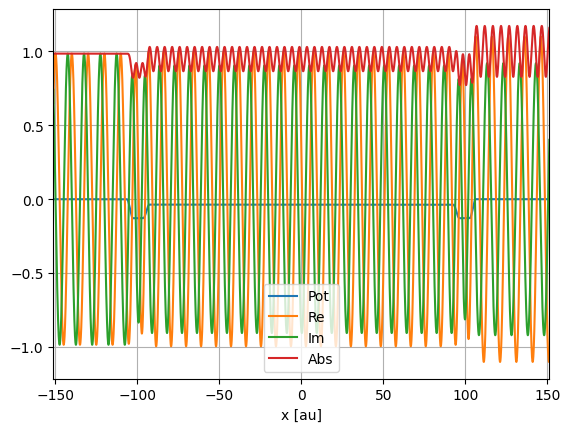

In [9]:
plt.plot(uxgrid,modelpot(0),label="Pot")
plt.plot(uxgrid,np.real(quasiparticle_mk["state"]["value"]),label="Re")
plt.plot(uxgrid,np.imag(quasiparticle_mk["state"]["value"]),label="Im")
plt.plot(uxgrid,np.abs(quasiparticle_mk["state"]["value"]),label="Abs")
plt.xlabel("x [au]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.grid()
plt.show()

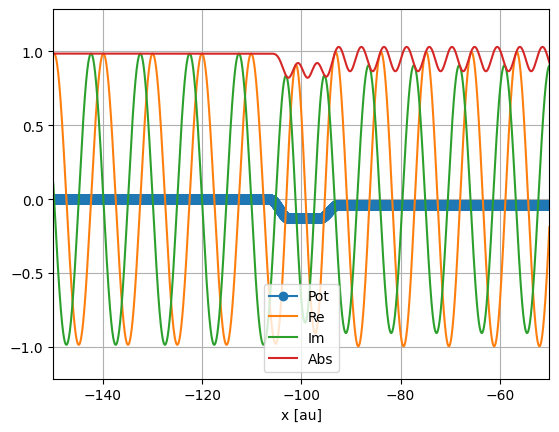

In [10]:
plt.plot(uxgrid,modelpot(0),"-o",label="Pot")
plt.plot(uxgrid,np.real(quasiparticle_mk["state"]["value"]),label="Re")
plt.plot(uxgrid,np.imag(quasiparticle_mk["state"]["value"]),label="Im")
plt.plot(uxgrid,np.abs(quasiparticle_mk["state"]["value"]),label="Abs")
plt.xlabel("x [au]")
plt.xlim([-150, -50])
plt.legend()
plt.grid()
plt.show()

In [11]:
t_vals=[]
r_vals=[]

energy_min = 0.18
energy_max = 0.22
k_min = dispersion.energy2k(energy_min)
k_max = dispersion.energy2k(energy_max)

k_vals=np.linspace(k_min,k_max,3)

print(k_min,k_max,k_vals)

e_vals=[]

# quasiparticles=[]

# eigen_states_pk=[]
# eigen_states_mk=[]

quasiparticles_pk=[]
quasiparticles_mk=[]

for k in k_vals:

    kin=k
    ein=dispersion.k2energy(k)
    e_vals.append(ein)

    #inistate_pk, inistate_mk = getIniStates(Ein,uxgrid,modelpot)
    # state_pk_norm, state_mk_norm = trat.normed_states_at_given_energy(ein,kin,ham_static)
    # eigen_states_pk.append(state_pk_norm)
    # eigen_states_mk.append(state_mk_norm)

    qp_pk, qp_mk = trat.quasiparticles_at_given_energy(ein,kin,ham_static)
    quasiparticles_pk.append(qp_pk)
    quasiparticles_mk.append(qp_mk)

    #trans,refl = get_t_and_r(Ein,uxgrid,uxgrid_dx,inistate_pk)
    #trans,refl = trat.transmission(kin,state_pk_norm),trat.reflexion(kin,state_pk_norm)

    t_vals.append(qp_pk['transmission'])
    r_vals.append(qp_pk['reflection'])

    print(kin)

0.6000056256000885 0.6633325595234375 [0.60000563 0.63166909 0.66333256]
0.6000056256000885
0.631669092561763
0.6633325595234375


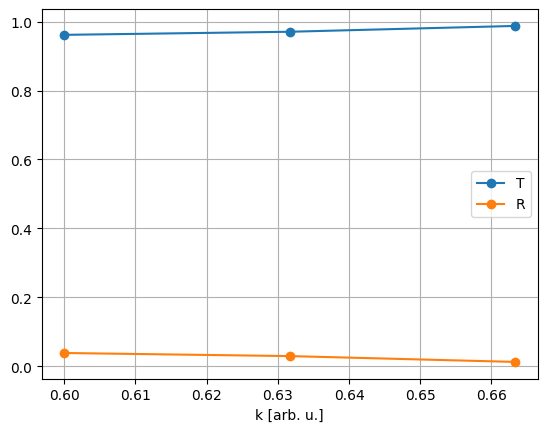

In [12]:
plt.plot(k_vals,t_vals,"-o",label="T")
plt.plot(k_vals,r_vals,"-o",label="R")
plt.xlabel("k [arb. u.]")
#plt.ylabel("Coefficient")
plt.legend()
plt.grid()
plt.show()

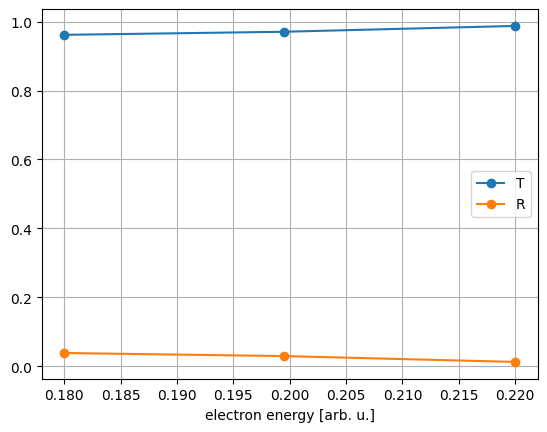

In [13]:
plt.plot(e_vals,t_vals,"-o",label="T")
plt.plot(e_vals,r_vals,"-o",label="R")
plt.xlabel("electron energy [arb. u.]")
#plt.ylabel("Coefficient")
plt.legend()
plt.grid()
plt.show()

# Laser potential

In [14]:
t_start=0
t_stop=1200.0
#t_num=10000

#utgrid=np.linspace(t_start,t_stop,t_num)
#utgrid_dt=utgrid[1]-utgrid[0]
utgrid_dt=0.1
utgrid=np.arange(t_start,t_stop,utgrid_dt)
t_num=len(utgrid)

#print(utgrid_dt)
print(t_num)

12000


In [15]:
laserpot_cep0 = pots.SmoothLaserPotential(uxgrid,\
                                    spatial_min = -0.35*modelpot.wellwidth,\
                                    spatial_max = 0.35*modelpot.wellwidth,beta=0.25)

#laserpot_cep0 = LaserPotential(uxgrid)

In [16]:
# X,Y = np.meshgrid(uxgrid,utgrid)

# Z=laserpot_cep0(Y)

# z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
# pcm = plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
# plt.colorbar(pcm)
 
# plt.title('External LASER field', fontweight ="bold")
# plt.ylim(laserpot_cep0.temporal_min,1.2*laserpot_cep0.temporal_max)
# #plt.xlim(2*laserpot_cep0.spatial_min,2*laserpot_cep0.spatial_max)
# plt.xlabel("x [arb. u.]")
# plt.ylabel("time [arb. u.]")
# plt.show()

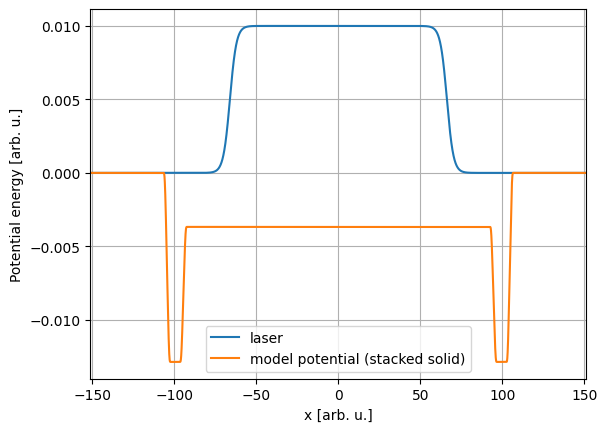

In [17]:
plt.plot(uxgrid, laserpot_cep0(laserpot_cep0.temporal_width/2),label="laser")
plt.plot(uxgrid, 0.1*modelpot(uxgrid),label="model potential (stacked solid)")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.xlabel("x [arb. u.]")
plt.ylabel("Potential energy [arb. u.]")
plt.grid()
plt.show()

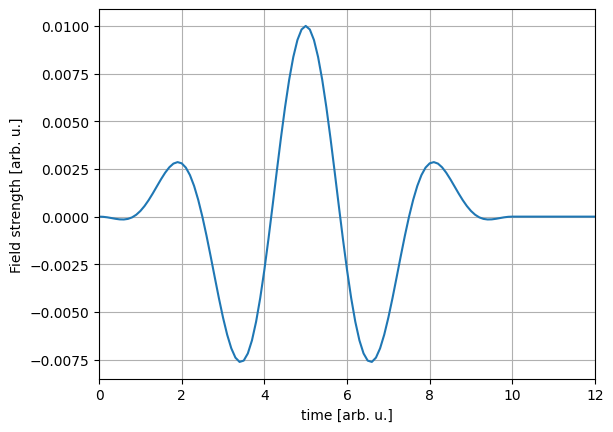

In [18]:
plt.plot(utgrid, laserpot_cep0.value_at(0.0,utgrid),label="laser")
plt.xlabel("time [arb. u.]")
plt.ylabel("Field strength [arb. u.]")
plt.xlim(0,1.2*laserpot_cep0.temporal_width)
plt.grid()
plt.show()

In [19]:
k_start=0.4
k_stop=1.0
omega_start = dispersion.k2energy(k_start)
omega_stop = dispersion.k2energy(k_stop)
print(omega_start)
print(omega_stop)

0.07999933328124322
0.49997395675651973


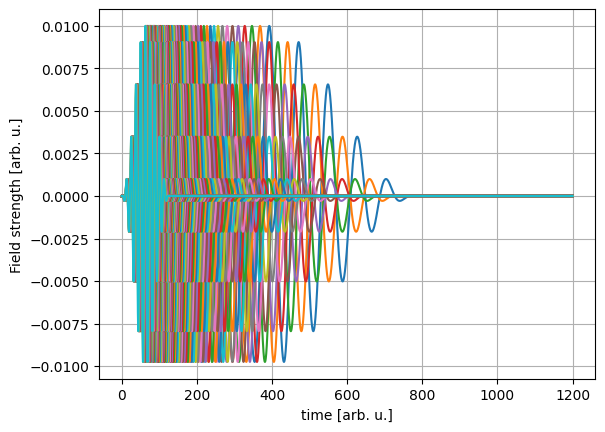

In [20]:
omegas=np.linspace(omega_start,omega_stop,80)

laser_potentials=[]
num_of_cycles=10
for w in omegas:
    tau=2*np.pi/w
    lp=pots.LaserPotential(uxgrid,noc=10,temporal_max=num_of_cycles*tau)
    laser_potentials.append(lp)
    plt.plot(utgrid, lp.value_at(0.0,utgrid),label="laser")

plt.xlabel("time [arb. u.]")
plt.ylabel("Field strength [arb. u.]")
#plt.xlim(0,1.2*laserpot_cep0.temporal_width)
plt.grid()
plt.show()

# One dimensional time-dependent Schrödinger equation solver with Crank-Nicholson scheme

to solve:
\begin{align}
i \hbar \frac{\partial}{\partial t} \ket{\Psi} &= \hat{H}(x,t) \ket{\Psi}\\
\frac{\partial}{\partial t} \ket{\Psi} &= -\frac{i}{\hbar} \hat{H}(x,t) \ket{\Psi}
\end{align}

In [21]:
nx=len(uxgrid)
nt=len(utgrid)

# Splitting:



\begin{align}
\hat{H}(x,t) &= \frac{(\hat{p}-e \hat{A}(x,t))^2}{2 m^*} + \hat{V}_s(x) + \hat{V}_e(x,t) = \frac{ \hat{p}^2-e \hat{p} \hat{A}(x,t) - e \hat{A}(x,t) \hat{p} + e^2 \hat{A}^2(x,t) }{2 m^*} + \hat{V}_s(x) + \hat{V}_e(x,t)\\
&=  \frac{ \hat{p}^2 }{2 m^*} + \hat{V}_s(x) + \frac{ e^2 \hat{A}^2(x,t) - e \hat{p} \hat{A}(x,t) - e \hat{A}(x,t) \hat{p} }{2 m^*} + \hat{V}_e(x,t) \\
 &=  \hat{H}_0(x,t) + \hat{H}_1(x,t)
\end{align}
thus
\begin{align}
i \hbar \frac{\partial}{\partial t} \ket{\Psi_1} = \hat{H}(x,t) \ket{\Psi_1}  + \hat{H}_1(x,t) \ket{\Psi_0}
\end{align}
if
\begin{align}
\ket{\Psi} = \ket{\Psi_0} + \ket{\Psi_1}
\end{align}
and
\begin{align}
\hat{H}_0(x,t) \ket{\Psi_0} = E_0 \ket{\Psi_0}
\end{align}


In [22]:
qppk=quasiparticles_pk[1]
qpmk=quasiparticles_mk[1]

print(qppk["energy"],qppk["wavenumber"])
print(qppk["energy"],qpmk["wavenumber"])

0.19949877496522261 0.631669092561763
0.19949877496522261 -0.631669092561763


In [ ]:
plt.plot(uxgrid,modelpot(0),label="Pot")
plt.plot(uxgrid,np.real(quasiparticle_mk["state"]["value"]),label="Re")
plt.plot(uxgrid,np.imag(quasiparticle_mk["state"]["value"]),label="Im")
plt.plot(uxgrid,np.abs(quasiparticle_mk["state"]["value"]),label="Abs")
plt.xlabel("x [au]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.grid()
plt.show()

In [ ]:
plt.plot(uxgrid,modelpot(0),"-o",label="Pot")
plt.plot(uxgrid,np.real(quasiparticle_mk["state"]["value"]),label="Re")
plt.plot(uxgrid,np.imag(quasiparticle_mk["state"]["value"]),label="Im")
plt.plot(uxgrid,np.abs(quasiparticle_mk["state"]["value"]),label="Abs")
plt.xlabel("x [au]")
plt.xlim([-150, -50])
plt.legend()
plt.grid()
plt.show()

In [23]:
v_cap=quat.vcap_generator(uxgrid,param_x0=250,param_lambda0 = 0.1)

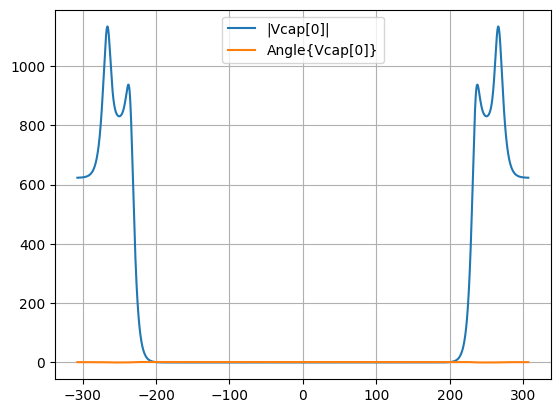

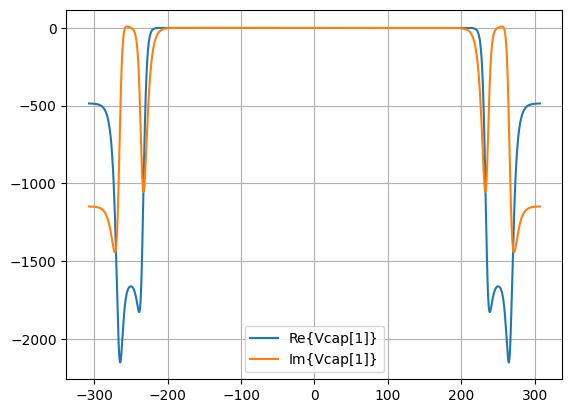

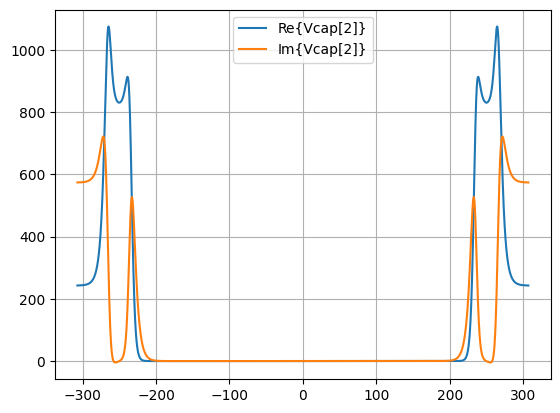

In [24]:
plt.plot(uxgrid,np.abs(v_cap[0]),label="|Vcap[0]|")
plt.plot(uxgrid,np.angle(v_cap[0]),label="Angle{Vcap[0]}")
plt.legend()
plt.grid()
plt.show()

plt.plot(uxgrid,np.real(v_cap[1]),label="Re{Vcap[1]}")
plt.plot(uxgrid,np.imag(v_cap[1]),label="Im{Vcap[1]}")
plt.legend()
plt.grid()
plt.show()

plt.plot(uxgrid,np.real(v_cap[2]),label="Re{Vcap[2]}")
plt.plot(uxgrid,np.imag(v_cap[2]),label="Im{Vcap[2]}")
plt.legend()
plt.grid()
plt.show()

## Advanced methode

In [25]:
psi0_pk_te = quat.eigenstate_time_evolution(omega=qppk["energy"]/quat.hartree_atomic_units["action"],\
                                             times=utgrid,\
                                             eigenstate = qppk["state"])

psi0_mk_te = quat.eigenstate_time_evolution(omega=qpmk["energy"]/quat.hartree_atomic_units["action"],\
                                             times=utgrid,\
                                             eigenstate = qpmk["state"])

In [26]:
psi_pk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qppk["energy"]/quat.hartree_atomic_units["action"],\
        psi0_initial = qppk["state"],\
        scalarpot = modelpot,\
        vectorpot=laserpot_cep0,\
        dt=utgrid_dt, t_start=t_start, t_stop=t_stop)

psi_mk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qpmk["energy"]/quat.hartree_atomic_units["action"],\
        psi0_initial = qpmk["state"],\
        scalarpot = modelpot,\
        vectorpot=laserpot_cep0,\
        dt=utgrid_dt, t_start=t_start, t_stop=t_stop)

In [27]:
psi_pk_te.run()

In [31]:
psi_mk_te.run()

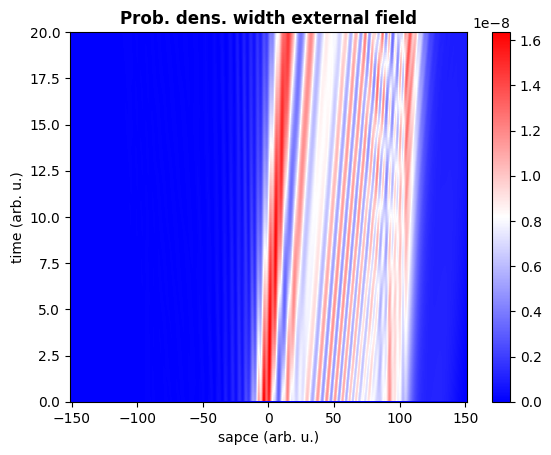

In [29]:
X,Y = np.meshgrid(uxgrid,utgrid)

Z=np.transpose(quat.probability_density(psi_pk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.ylim(0,2*laserpot_cep0.temporal_width)
plt.show()

In [37]:
X,Y = np.meshgrid(uxgrid,utgrid)

Z=np.transpose(quat.probability_density(psi_pk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr',vmax=1e-10) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)

plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.9*modelpot.wellwidth, 0.9*modelpot.wellwidth])
plt.ylim(2*laserpot_cep0.temporal_width,1200)
plt.show()

: 

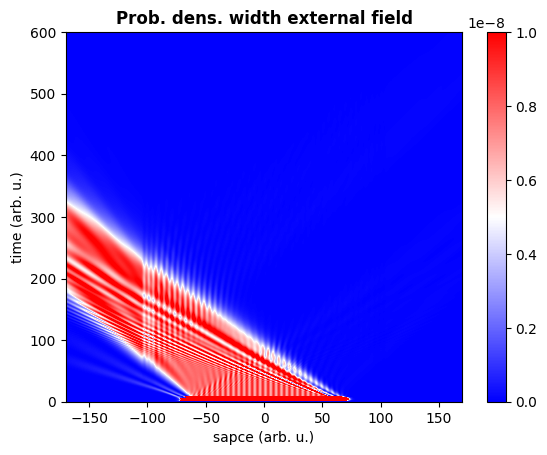

In [ ]:
X,Y = np.meshgrid(uxgrid,utgrid)

Z=np.transpose(quat.probability_density(psi_mk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr',vmax=1e-8) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.9*modelpot.wellwidth, 0.9*modelpot.wellwidth])
plt.ylim(0,600)#2*laserpot_cep0.temporal_width)
plt.show()

# Compute probability current

In [29]:
meas_point_left=-150
meas_point_right=-meas_point_left

left_index = np.abs(np.array(uxgrid) - meas_point_left).argmin()#1300
right_index = np.abs(np.array(uxgrid) - meas_point_right).argmin()#
x_left = uxgrid[left_index]
x_right = uxgrid[right_index]

print(x_left,x_right)

-149.99360325534082 149.99360325534082


In [32]:
pc2_pk=quat.probability_current(psi_pk_te.psi_time_evolution)
pc2_mk=quat.probability_current(psi_mk_te.psi_time_evolution)

pc2_sum=pc2_pk+pc2_mk

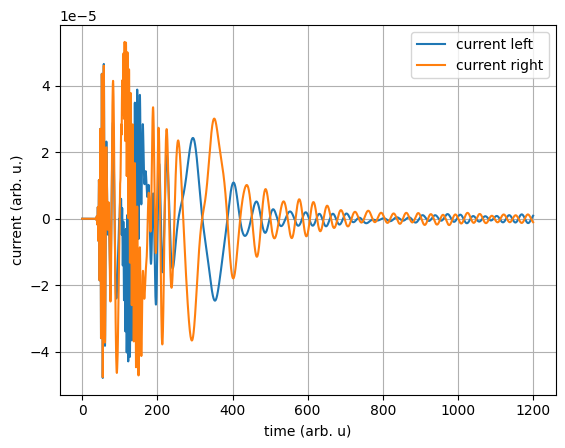

In [33]:
pc_sum_left=pc2_sum[left_index,:]
pc_sum_right=pc2_sum[right_index,:]
#pcsum_diff=pcsum_right-pcsum_left

plt.plot(utgrid, pc_sum_left,label="current left")
plt.plot(utgrid, pc_sum_right,label="current right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()

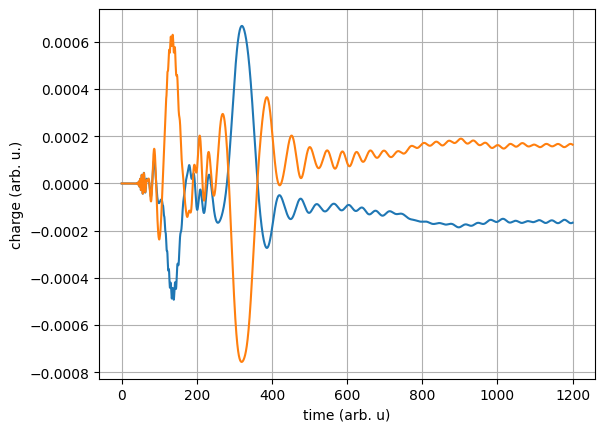

In [34]:
from scipy import integrate

charge_left = integrate.cumtrapz(pc_sum_left, utgrid, initial=0)
charge_right = integrate.cumtrapz(pc_sum_right, utgrid, initial=0)
#charge_diff = integrate.cumtrapz(pcsum_diff, utgrid, initial=0)

plt.plot(utgrid, charge_left,label="charge left")
plt.plot(utgrid, charge_right,label="charge right")
#plt.plot(utgrid, charge_left+charge_right)
#plt.plot(utgrid, charge_diff)
plt.xlabel("time (arb. u)")
plt.ylabel("charge (arb. u.)")
#plt.xlim(100)
#plt.ylim(-1e-3,1e-3)
plt.grid()
plt.show()

# Parameter Scans

In [40]:
span = np.array([6, 13])#np.where((k_vals>k_start) & (k_vals<k_stop))[0]
print(span)
print(k_vals[span])
print(e_vals[13])

[ 6 13]
[0.32263158 0.68736842]
0.23615464528963614


In [41]:
import pickle

# psi_pks=[]
# psi_mks=[]

filename="/home/magashegyi/Results/negf/state_time_evolutions_3f.pkl"

run_num=1

# Serialize the object to a binary format
with open(filename, 'wb') as file:

    for i in span:
    
        kin=k_vals[i]
        ein=e_vals[i]
        qpk=quasiparticles_pk[i]
        qmk=quasiparticles_mk[i]

        for lp,j in zip(laser_potentials,range(len(laser_potentials))):

            print(str(run_num)+". run:")
            print("-electron energy:"+str(ein))
            print("-electron wavenumber:"+str(kin))
            print("-pulse width:"+str(lp.temporal_width))
            print("-pulse omega0:"+str(lp.omega0))

            #psi0_pk_te = quat.eigenstate_time_evolution(omega=qpk["energy"]/hham.hbar, times=utgrid,\
            #                    eigenstate = qpk["state"])

            #psi0_mk_te = quat.eigenstate_time_evolution(omega=qmk["energy"]/hham.hbar, times=utgrid,\
            #                    eigenstate = qmk["state"])
            
            psipk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qpk["energy"]/hham.hbar,\
                                                        psi0_initial = qpk["state"],\
                                                        scalarpot = modelpot,\
                                                        vectorpot=lp,\
                                                        dt=utgrid_dt, t_start=t_start, t_stop=t_stop)

            psimk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qmk["energy"]/hham.hbar,\
                                                        psi0_initial = qmk["state"],\
                                                        scalarpot = modelpot,\
                                                        vectorpot=lp,\
                                                        dt=utgrid_dt, t_start=t_start, t_stop=t_stop)
            
            psipk_te.run()
            psimk_te.run()

            run_num+=1
            #psi_pks.append(psi_pk_te)
            #psi_mks.append(psi_mk_te)
            # pickle.dump(psipk_te, file)
            # pickle.dump(psimk_te, file)

            # qppk= QuasiParticle( charge=ham.charge, mass=ham.mass,\
            #     state=nstatepk,energy=ein, wavenumber=kin,\
            #     amplitudes = amplitudes(kin,nstatepk),\
            #     transmission = transmission(kin,nstatepk),\
            #     reflection = reflection(kin,nstatepk))
        
            # qpmk= QuasiParticle(charge=ham.charge, mass=ham.mass,\
            #     state=nstatemk,energy=ein, wavenumber=-kin,\
            #     amplitudes = amplitudes(-kin,nstatemk),\
            #     transmission = transmission(-kin,nstatemk),\
            #     reflection = reflection(-kin,nstatemk))

            pickle.dump(psipk_te.psi1timeevolution, file)
            pickle.dump(psimk_te.psi1timeevolution, file)

            X,Y = np.meshgrid(uxgrid,utgrid)

            Z=np.transpose(quat.probability_density(psipk_te.psi1timeevolution))

            #z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
                
            pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
            plt.colorbar(pcm)
            
            plt.title('Prob. dens. width external field', fontweight ="bold")
            plt.xlabel("sapce (arb. u.)")
            plt.ylabel("time (arb. u.)")
            plt.xlim(-15,15)
            plt.ylim(0,2*lp.temporal_width)
            plt.show()

            X,Y = np.meshgrid(uxgrid,utgrid)

            Z=np.transpose(quat.probability_density(psimk_te.psi1timeevolution))

            #z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
                
            pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
            plt.colorbar(pcm)
            
            plt.title('Prob. dens. width external field', fontweight ="bold")
            plt.xlabel("sapce (arb. u.)")
            plt.ylabel("time (arb. u.)")
            plt.xlim(-15,15)
            plt.ylim(0,2*lp.temporal_width)
            plt.show()

            pc_pk=quat.probability_current(psipk_te.psitimeevolution)
            pc_mk=quat.probability_current(psimk_te.psitimeevolution)

            pc_sum=pc_pk+pc_mk

            pc_sum_left=pc_sum[left_index,:]
            pc_sum_right=pc_sum[right_index,:]
            #pcsum_diff=pcsum_right-pcsum_left

            plt.plot(utgrid, pc_sum_left,label="current left")
            plt.plot(utgrid, pc_sum_right,label="current right")
            #plt.plot(utgrid, pcsum_diff,label="current difference")
            plt.xlabel("time (arb. u)")
            plt.ylabel("current (arb. u.)")
            #plt.xlim(0,5*lp.temporal_width)
            plt.legend()
            #plt.ylim(-1e-5,1e-5)
            plt.grid()
            plt.show()

            charge_left = integrate.cumtrapz(pc_sum_left, utgrid, initial=0)
            charge_right = integrate.cumtrapz(pc_sum_right, utgrid, initial=0)
            #charge_diff = integrate.cumtrapz(pcsum_diff, utgrid, initial=0)

            plt.plot(utgrid, charge_left,label="charge left")
            plt.plot(utgrid, charge_right,label="charge right")
            #plt.plot(utgrid, charge_left+charge_right)
            #plt.plot(utgrid, charge_diff)
            plt.xlabel("time (arb. u)")
            plt.ylabel("charge (arb. u.)")
            #plt.xlim(100)
            #plt.ylim(-1e-3,1e-3)
            plt.grid()
            plt.show()


1. run:
-electron energy:0.0520415375376378
-electron wavenumber:0.32263157894736844
-pulse width:785.4916603336312
-pulse omega0:0.07999047761386613


NameError: name 'hham' is not defined

In [ ]:
import pickle

# psi_pks=[]
# psi_mks=[]

filename="/home/magashegyi/Results/negf/state_time_evolutions_3f.pkl"

run_num=1

energy_of_electrons=[e_vals[i] for i in span]
energy_of_photons=[ lp.omega0*hham.hbar for lp in laser_potentials]
charge_diffs=[]

# Serialize the object to a binary format
with open(filename, 'rb') as file:

    for i in span:
    
        kin=k_vals[i]
        ein=e_vals[i]
        qpk=quasiparticles_pk[i]
        qmk=quasiparticles_mk[i]

        for lp,j in zip(laser_potentials,range(len(laser_potentials))):

            print(str(run_num)+". run:")
            # print("-electron energy:"+str(ein))
            # print("-electron wavenumber:"+str(kin))
            # print("-pulse width:"+str(lp.temporal_width))
            # print("-pulse omega0:"+str(lp.omega0))

            psi0_pk_te = quat.eigenstate_time_evolution(omega=qpk["energy"]/hham.hbar, times=utgrid,\
                                eigenstate = qpk["state"])

            psi0_mk_te = quat.eigenstate_time_evolution(omega=qmk["energy"]/hham.hbar, times=utgrid,\
                                eigenstate = qmk["state"])
            

            loaded_psi1_te_pk = pickle.load(file)
            loaded_psi1_te_mk = pickle.load(file)

            psi_pk_value = loaded_psi1_te_pk["value"] + psi0_pk_te["value"]
            psi_mk_value = loaded_psi1_te_mk["value"] + psi0_mk_te["value"]

            psipk_te=quat.Wavefunction(grid=psi0_pk_te["grid"],value=psi_pk_value)
            psimk_te=quat.Wavefunction(grid=psi0_mk_te["grid"],value=psi_mk_value)

            run_num+=1

            pc_pk=quat.probability_current(psipk_te)
            pc_mk=quat.probability_current(psimk_te)

            pc_sum=pc_pk+pc_mk

            pc_sum_left=pc_sum[left_index,:]
            pc_sum_right=pc_sum[right_index,:]
            #pcsum_diff=pcsum_right-pcsum_left

            # plt.plot(utgrid, pc_sum_left,label="current left")
            # plt.plot(utgrid, pc_sum_right,label="current right")
            # #plt.plot(utgrid, pcsum_diff,label="current difference")
            # plt.xlabel("time (arb. u)")
            # plt.ylabel("current (arb. u.)")
            # #plt.xlim(0,5*lp.temporal_width)
            # plt.legend()
            # #plt.ylim(-1e-5,1e-5)
            # plt.grid()
            # plt.show()

            charge_left = integrate.cumtrapz(pc_sum_left, utgrid, initial=0)
            charge_right = integrate.cumtrapz(pc_sum_right, utgrid, initial=0)
            #charge_diff = integrate.cumtrapz(pcsum_diff, utgrid, initial=0)

            end_index=len(utgrid)-2000
            average_time = utgrid[-1]-utgrid[end_index]
            charge_on_end_left = charge_left[end_index:]
            charge_on_end_right = charge_right[end_index:]
            utgrid_on_end = utgrid[end_index:]

            average_charge_on_end_left = (integrate.cumtrapz(charge_on_end_left, utgrid_on_end, initial=0)[-1]/average_time)*np.ones_like(utgrid_on_end)
            average_charge_on_end_right = (integrate.cumtrapz(charge_on_end_right, utgrid_on_end, initial=0)[-1]/average_time)*np.ones_like(utgrid_on_end)

            # plt.plot(utgrid, charge_left,label="charge left")
            # plt.plot(utgrid, charge_right,label="charge right")
            # # plt.plot(utgrid_on_end, charge_on_end_left)
            # # plt.plot(utgrid_on_end, charge_on_end_right)
            # plt.plot(utgrid_on_end, average_charge_on_end_left)
            # plt.plot(utgrid_on_end, average_charge_on_end_right)
            # plt.xlabel("time (arb. u)")
            # plt.ylabel("charge (arb. u.)")
            # #plt.xlim(100)
            # #plt.ylim(-1e-3,1e-3)
            # plt.grid()
            # plt.show()

            charge_diffs.append(average_charge_on_end_left[-1]-average_charge_on_end_right[-1])




1. run:
2. run:
3. run:
4. run:
5. run:
6. run:
7. run:
8. run:
9. run:
10. run:
11. run:
12. run:
13. run:
14. run:
15. run:
16. run:
17. run:
18. run:
19. run:
20. run:
21. run:
22. run:
23. run:
24. run:
25. run:
26. run:
27. run:
28. run:
29. run:
30. run:
31. run:
32. run:
33. run:
34. run:
35. run:
36. run:
37. run:
38. run:
39. run:
40. run:
41. run:
42. run:
43. run:
44. run:
45. run:
46. run:
47. run:
48. run:
49. run:
50. run:
51. run:
52. run:
53. run:
54. run:
55. run:
56. run:
57. run:
58. run:
59. run:
60. run:
61. run:
62. run:
63. run:
64. run:
65. run:
66. run:
67. run:
68. run:
69. run:
70. run:
71. run:
72. run:
73. run:
74. run:
75. run:
76. run:
77. run:
78. run:
79. run:
80. run:
81. run:
82. run:
83. run:
84. run:
85. run:
86. run:
87. run:
88. run:
89. run:
90. run:
91. run:
92. run:
93. run:
94. run:
95. run:
96. run:
97. run:
98. run:
99. run:
100. run:
101. run:
102. run:
103. run:
104. run:
105. run:
106. run:
107. run:
108. run:
109. run:
110. run:
111. run

In [ ]:
print(charge_diffs)

[-0.04981876984826132, -0.050311880125120306, -0.05049725860827551, -0.050017001235526735, -0.049254273992227704, -0.04831136306106493, -0.04698817085823921, -0.045355864613266815, -0.044008872173722624, -0.04265410398891054, -0.040789772620496434, -0.03703915962572351, -0.013744272912708527, 0.04714485754340504, 0.12318267901048424, 0.16641325514240557, 0.15457279499915832, 0.10542099891225166, 0.05073362569593861, 0.010824721201599025, -0.010576915832465306, -0.01881005375875621, -0.02040891585628072, -0.01964094794845282, -0.018391076578698186, -0.017166772568933068, -0.015974115442355837, -0.01476765469852594, -0.013577984052976826, -0.01248449002125228, -0.011554459714059193, -0.010807862374005713, -0.010218426955261336, -0.009735910088084582, -0.009310274552336304, -0.00890636644624504, -0.008507286503918415, -0.008110320633254807, -0.007720391594051294, -0.007344451204059009, -0.006988142294654116, -0.006654583900896879, -0.006344512554997945, -0.006057000922378293, -0.005790230

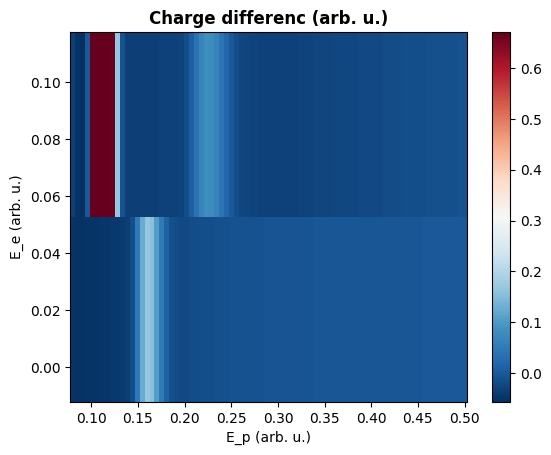

In [ ]:
import matplotlib.colors as colors

X,Y = np.meshgrid(energy_of_photons,energy_of_electrons)

Z=np.array(charge_diffs).reshape(len(energy_of_electrons),len(energy_of_photons))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='RdBu_r',vmin = Z.min(), vmax = 0.25*Z.max()) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
#pcm = plt.pcolormesh(X,Y,Z,cmap ='RdBu_r',shading='nearest',norm=colors.LogNorm(vmin=np.abs(Z.min()), vmax=np.abs(Z.max())))
plt.colorbar(pcm)
 
plt.title('Charge differenc (arb. u.)', fontweight ="bold")
plt.xlabel("E_p (arb. u.)")
plt.ylabel("E_e (arb. u.)")
#plt.xlim(-15,15)
#plt.ylim(0,2*laserpot_cep0.temporal_width)
plt.show()

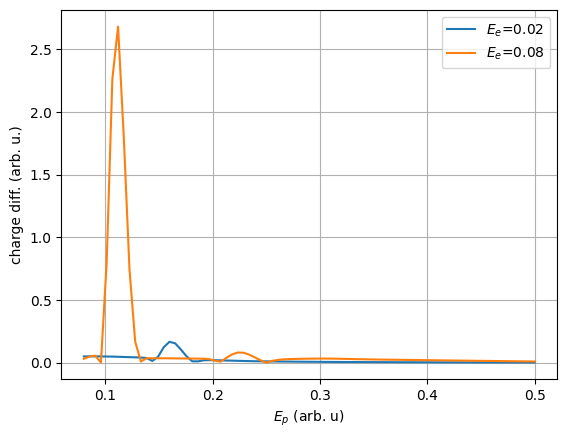

In [ ]:
#plt.plot(energy_of_photons, charge_diffs[:len(energy_of_photons)])
plt.plot(energy_of_photons,np.abs(Z[0,:]),label="$E_e$=0.02")
plt.plot(energy_of_photons,np.abs(Z[1,:]),label="$E_e$=0.08")
plt.xlabel("$E_p$ (arb. u)")
plt.ylabel("charge diff. (arb. u.)")
#plt.xlim(100)
#plt.ylim(-1e-3,1e-3)
plt.yscale("linear")
plt.legend()
plt.grid()
plt.show()